In [ ]:
!pip install unidecode -q
!pip install rdkit -q

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import unidecode
import random
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import json
import csv
import re
import gzip
import urllib.request
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED, AllChem, DataStructs
import warnings
warnings.filterwarnings('ignore')

TOKENIZER_NAME = "kmer"
K = 3                      # k-mer length (hyperparameter of this tokenizer)

In [ ]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
# Load and preprocess data
try:
    text = unidecode.unidecode(open('data_for_generation_mol.txt').read())
    print(f"✅ Data loaded: {len(text):,} characters")
except:
    print("⚠️ Data file not found. Please update the file path.")

smiles_list = re.findall(r'<([^<>]+)>', text)
print(f"🧪 Total molecules: {len(smiles_list):,}")
print(f"🔬 Sample molecules: {smiles_list[:3]}")

✅ Data loaded: 75,602,998 characters
🧪 Total molecules: 1,498,669
🔬 Sample molecules: ['COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O)C5=C4OC(C)(C)[C@@H]6COc7cc(OC)ccc7[C@H]56', 'C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4ccncc4', 'CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N']


## Tokenization (k-mer, k=3, non-overlapping)

`<` and `>` are kept as dedicated single-character sentinel tokens (needed for
the model's start/stop generation logic); k-mer chunking applies only to the
SMILES content between them.

In [ ]:
class KmerTokenizer:
    """Non-overlapping fixed-length k-mer tokenizer. Losslessly reversible
    by simple concatenation of chunks."""

    def __init__(self, k=3):
        self.k = k
        self.vocab = []
        self.stoi = {}
        self.itos = {}
        self.vocab_size = 0

    def _chunk(self, smiles):
        return [smiles[i:i+self.k] for i in range(0, len(smiles), self.k)]

    def build_vocab(self, smiles_list, min_freq=1):
        print(f"🔬 Building k-mer vocabulary (k={self.k})...")
        all_tokens = []
        for i, smi in enumerate(smiles_list):
            if i % 300000 == 0 and i > 0:
                print(f"  Processed {i:,}/{len(smiles_list):,} molecules...")
            chunks = self._chunk(smi)
            all_tokens.append('<')
            all_tokens.extend(chunks)
            all_tokens.append('>')

        token_counts = Counter(all_tokens)
        special_tokens = ['<PAD>', '<UNK>']
        regular_tokens = [tok for tok, c in token_counts.most_common() if c >= min_freq and tok not in ('<', '>')]
        self.vocab = special_tokens + ['<', '>'] + regular_tokens
        self.vocab_size = len(self.vocab)
        self.stoi = {t: i for i, t in enumerate(self.vocab)}
        self.itos = {i: t for i, t in enumerate(self.vocab)}
        print(f"✅ Vocabulary built: {self.vocab_size:,} unique {self.k}-mers (+ 4 special/sentinel tokens)")
        return self.vocab_size

    def encode(self, smiles):
        chunks = self._chunk(smiles)
        tokens = ['<'] + chunks + ['>']
        return [self.stoi.get(t, self.stoi['<UNK>']) for t in tokens]

    def decode(self, indices):
        tokens = [self.itos.get(i, '<UNK>') for i in indices]
        tokens = [t for t in tokens if t not in ('<PAD>', '<UNK>', '<', '>')]
        return ''.join(tokens)

    def save(self, filepath):
        import pickle
        with open(filepath, 'wb') as f:
            pickle.dump({'k': self.k, 'vocab': self.vocab, 'stoi': self.stoi,
                         'itos': self.itos, 'vocab_size': self.vocab_size}, f)
        print(f"💾 Tokenizer saved to {filepath}")

    def load(self, filepath):
        import pickle
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.k = data['k']; self.vocab = data['vocab']; self.stoi = data['stoi']
        self.itos = data['itos']; self.vocab_size = data['vocab_size']
        print(f"📂 Tokenizer loaded from {filepath}")
        return self

In [ ]:
# Sanity check: verify lossless round-trip on a few real molecules
_tok_test = KmerTokenizer(k=K)
_test_cases = smiles_list[:5]
_n_pass = 0
for _smi in _test_cases:
    _ids_raw = ['<'] + _tok_test._chunk(_smi) + ['>']
    _reconstructed = ''.join(t for t in _ids_raw if t not in ('<', '>'))
    _ok = (_reconstructed == _smi)
    _n_pass += _ok
    print(f"{'✅' if _ok else '❌'} {_smi[:50]}")
print(f"\n{_n_pass}/{len(_test_cases)} lossless round-trip checks passed")
assert _n_pass == len(_test_cases), "k-mer chunking round-trip FAILED -- do not proceed!"
print("✅ Chunking mechanism verified lossless")

✅ COc1ccc2[C@@H]3[C@H](COc2c1)C(C)(C)OC4=C3C(=O)C(=O
✅ C[S+]([O-])c1ccc(cc1)c2nc(c3ccc(F)cc3)c([nH]2)c4cc
✅ CC1(C)Oc2ccc(cc2[C@H]([C@@H]1O)N3CCCC3=O)C#N
✅ OC(=O)COCCN1CCN(CC1)C(c2ccccc2)c3ccc(Cl)cc3
✅ Ic1ccc(NC2=Nc3ccccc3C(=O)O2)cc1

5/5 lossless round-trip checks passed
✅ Chunking mechanism verified lossless


In [ ]:
tokenizer = KmerTokenizer(k=K)
vocab_size = tokenizer.build_vocab(smiles_list, min_freq=1)
print(f"\n📏 Final vocabulary size: {vocab_size}")
print(f"🔍 Sample k-mers: {tokenizer.vocab[10:30]}")

🔬 Building k-mer vocabulary (k=3)...
  Processed 300,000/1,498,669 molecules...
  Processed 600,000/1,498,669 molecules...
  Processed 900,000/1,498,669 molecules...
  Processed 1,200,000/1,498,669 molecules...
✅ Vocabulary built: 4,648 unique 3-mers (+ 4 special/sentinel tokens)

📏 Final vocabulary size: 4648
🔍 Sample k-mers: ['1cc', 'CC(', 'c2c', 'c3c', '[C@', 'COc', '@H]', 'O)N', '(C)', 'c(C', 'c(c', 'O)c', ')cc', ')C(', '2cc', '3cc', 'O)C', 'Cc1', 'cc2', '(CC']


In [ ]:
# Full dataset encoding
print("="*70)
print("📈 ENCODING FULL DATASET")
print("="*70)

all_encoded = []
for i, smi in enumerate(smiles_list):
    if i % 300000 == 0 and i > 0:
        print(f"  Encoding molecule {i:,}/{len(smiles_list):,}")
    all_encoded.extend(tokenizer.encode(smi))

data = torch.tensor(all_encoded, dtype=torch.long)
compression_ratio = len(text) / len(all_encoded)

print(f"\n📈 Encoded dataset shape: {data.shape}, dtype: {data.dtype}")
print(f"📏 Total tokens: {len(data):,}")
print(f"📚 Vocabulary size: {vocab_size}")
print(f"📐 Compression ratio (chars/token): {compression_ratio:.2f}x")

tokenizer.save(f'{TOKENIZER_NAME}_tokenizer.pkl')

📈 ENCODING FULL DATASET
  Encoding molecule 300,000/1,498,669
  Encoding molecule 600,000/1,498,669
  Encoding molecule 900,000/1,498,669
  Encoding molecule 1,200,000/1,498,669

📈 Encoded dataset shape: torch.Size([27699175]), dtype: torch.int64
📏 Total tokens: 27,699,175
📚 Vocabulary size: 4648
📐 Compression ratio (chars/token): 2.73x
💾 Tokenizer saved to kmer_tokenizer.pkl


## Data Splitting and Batch Generation

In [ ]:
# Hyperparameters (fixed across ALL tokenizer conditions for a fair, controlled comparison)
batch_size = 32
block_size = 256
learning_rate = 1e-4
n_head = 12
n_embd = n_head * 32
ff_size_factor = 4
n_layer = 12
dropout = 0.15

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

🖥️ Using device: cuda


In [ ]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"📊 Train data: {len(train_data):,} tokens")
print(f"📊 Val data: {len(val_data):,} tokens")

📊 Train data: 24,929,257 tokens
📊 Val data: 2,769,918 tokens


In [ ]:
def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch('train')
print(f"🔢 Batch shapes -> Input: {xb.shape}, Target: {yb.shape}")
print(f"\n📝 Sample decoded training sequence:")
print(f"  '{tokenizer.decode(xb[0][:20].cpu().tolist())}'")

🔢 Batch shapes -> Input: torch.Size([32, 256]), Target: torch.Size([32, 256])

📝 Sample decoded training sequence:
  'C)Cc1cn(c2nc(CN3CCCC3)cs2)c4cc(Cl)ccc14CC(=O)Nc1ccc(cc'


## Model Architecture

In [ ]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * (self.head_size ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, ff_size_factor * n_embd),
            nn.GELU(),
            nn.Linear(ff_size_factor * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DrugGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, eos_token, temperature=1.0, top_k=None):
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                idx_cond = idx[:, -block_size:]
                logits, _ = self(idx_cond)
                logits = logits[:, -1, :] / temperature
                if top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float('Inf')
                probs = F.softmax(logits, dim=-1)
                idx_next = torch.multinomial(probs, num_samples=1)
                if idx_next.item() == eos_token:
                    break
                idx = torch.cat((idx, idx_next), dim=1)
        self.train()
        return idx

model = DrugGPT()
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔧 Model created successfully!")
print(f"📊 Total parameters: {total_params/1e6:.2f}M")
print(f"🏋️ Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"💾 Model size: ~{total_params * 4 / 1e6:.1f}MB")

🔧 Model created successfully!
📊 Total parameters: 24.95M
🏋️ Trainable parameters: 24.95M
💾 Model size: ~99.8MB


## Training configuration

In [ ]:
max_iters = 25000
eval_interval = 200
eval_iters = 100
save_interval = 1000
save_path = f"drugGPT_{TOKENIZER_NAME}.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate*0.1)

tokens_per_step = batch_size * block_size
total_tokens_sampled = tokens_per_step * max_iters
effective_epochs = total_tokens_sampled / len(train_data)
estimated_unique_coverage = 1 - math.exp(-total_tokens_sampled / len(train_data))

print(f"📐 Tokenizer: {TOKENIZER_NAME} (k={K})")
print(f"📐 Vocabulary size: {vocab_size}")
print(f"📐 Compression ratio (chars/token): {compression_ratio:.2f}x")
print(f"📐 Training set size: {len(train_data):,} tokens")
print(f"📐 Total tokens sampled over {max_iters:,} steps: {total_tokens_sampled:,}")
print(f"📐 Effective epochs: {effective_epochs:.2f}")
print(f"📐 Estimated unique-position coverage: {estimated_unique_coverage*100:.1f}%")

training_config = {
    "tokenizer": TOKENIZER_NAME,
    "k": K,
    "vocab_size": vocab_size,
    "compression_ratio": round(compression_ratio, 3),
    "train_set_size_tokens": len(train_data),
    "val_set_size_tokens": len(val_data),
    "batch_size": batch_size, "block_size": block_size, "learning_rate": learning_rate,
    "n_head": n_head, "n_embd": n_embd, "n_layer": n_layer, "dropout": dropout,
    "optimizer": "AdamW", "weight_decay": 0.01, "lr_scheduler": "CosineAnnealingLR",
    "max_iters": max_iters,
    "effective_epochs": round(effective_epochs, 3),
    "estimated_unique_coverage_pct": round(estimated_unique_coverage*100, 2),
    "total_params_M": round(total_params/1e6, 3),
}
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"\n💾 Saved training_config_{TOKENIZER_NAME}.json")

📐 Tokenizer: kmer (k=3)
📐 Vocabulary size: 4648
📐 Compression ratio (chars/token): 2.73x
📐 Training set size: 24,929,257 tokens
📐 Total tokens sampled over 25,000 steps: 204,800,000
📐 Effective epochs: 8.22
📐 Estimated unique-position coverage: 100.0%

💾 Saved training_config_kmer.json


In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## Training Loop

🚀 Starting training for 25000 iterations...
Step     0 | Train: 8.5316 | Val: 8.5282 | LR: 1.00e-04 | Time: 15.9s
💾 Checkpoint saved at iteration 0
Step   200 | Train: 3.5226 | Val: 3.6002 | LR: 1.00e-04 | Time: 67.6s
Step   400 | Train: 3.2002 | Val: 3.2896 | LR: 9.99e-05 | Time: 130.0s
Step   600 | Train: 3.0346 | Val: 3.1281 | LR: 9.99e-05 | Time: 192.6s
Step   800 | Train: 2.7969 | Val: 2.9072 | LR: 9.98e-05 | Time: 254.9s
Step  1000 | Train: 2.6109 | Val: 2.7251 | LR: 9.96e-05 | Time: 316.9s
💾 Checkpoint saved at iteration 1000
Step  1200 | Train: 2.4688 | Val: 2.5685 | LR: 9.95e-05 | Time: 381.1s
Step  1400 | Train: 2.3558 | Val: 2.4695 | LR: 9.93e-05 | Time: 417.6s
Step  1600 | Train: 2.2574 | Val: 2.3776 | LR: 9.91e-05 | Time: 480.2s
Step  1800 | Train: 2.1901 | Val: 2.3058 | LR: 9.89e-05 | Time: 542.1s
Step  2000 | Train: 2.1347 | Val: 2.2503 | LR: 9.86e-05 | Time: 604.6s
💾 Checkpoint saved at iteration 2000
Step  2200 | Train: 2.0774 | Val: 2.2164 | LR: 9.83e-05 | Time: 667.6

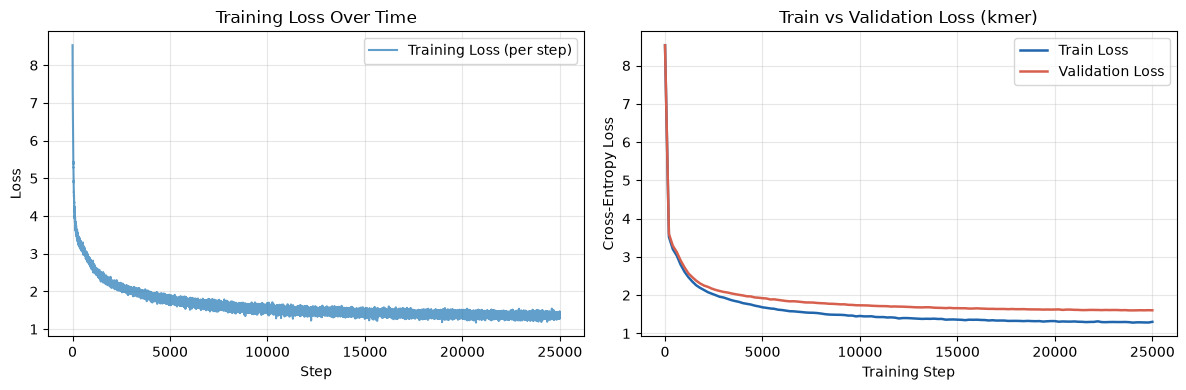

📊 Final Training Loss: 1.3024
📊 Final Validation Loss: 1.6047
💾 Updated training_config_kmer.json


In [ ]:
resume_training = os.path.exists(save_path)
start_iter = 0

if resume_training:
    print(f"🔄 Resuming from checkpoint: {save_path}")
    try:
        checkpoint = torch.load(save_path, map_location=device)
        if isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_iter = checkpoint.get('iteration', 0)
            print(f"📍 Resuming from iteration {start_iter}")
        else:
            model = checkpoint
            model.to(device)
    except Exception as e:
        print(f"⚠️ Error loading checkpoint: {e}")
        resume_training = False

losses = []
train_losses = []
val_losses = []
eval_step_numbers = []
start_time = time.time()

print(f"🚀 Starting training for {max_iters} iterations...")

for iter_num in range(start_iter, max_iters):
    if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
        losses_dict = estimate_loss()
        train_loss = losses_dict['train']
        val_loss = losses_dict['val']
        train_losses.append(float(train_loss))
        val_losses.append(float(val_loss))
        eval_step_numbers.append(iter_num)
        elapsed_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Step {iter_num:5d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {current_lr:.2e} | Time: {elapsed_time:.1f}s")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    if iter_num % save_interval == 0 or iter_num == max_iters - 1:
        checkpoint = {
            'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),
            'iteration': iter_num, 'eval_step_numbers': eval_step_numbers,
            'train_losses': train_losses, 'val_losses': val_losses,
            'config': {'vocab_size': vocab_size, 'block_size': block_size, 'n_embd': n_embd,
                       'n_head': n_head, 'n_layer': n_layer, 'dropout': dropout}
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at iteration {iter_num}")

total_time = time.time() - start_time
print(f"\n✅ Training completed! Total time: {total_time/60:.1f} min")

csv_path = f"loss_curve_data_{TOKENIZER_NAME}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    for s, tr, va in zip(eval_step_numbers, train_losses, val_losses):
        writer.writerow([s, tr, va])
print(f"💾 Saved raw loss curve data: {csv_path}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.7, label='Training Loss (per step)')
plt.title('Training Loss Over Time'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(eval_step_numbers, train_losses, '-', color='#2166AC', linewidth=1.8, label='Train Loss')
plt.plot(eval_step_numbers, val_losses, '-', color='#D6604D', linewidth=1.8, label='Validation Loss')
plt.title(f'Train vs Validation Loss ({TOKENIZER_NAME})')
plt.xlabel('Training Step'); plt.ylabel('Cross-Entropy Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"loss_curve_{TOKENIZER_NAME}.png", dpi=300)
plt.show()

print(f"📊 Final Training Loss: {train_losses[-1]:.4f}")
print(f"📊 Final Validation Loss: {val_losses[-1]:.4f}")

training_config.update({
    "final_train_loss": round(float(train_losses[-1]), 4),
    "final_val_loss": round(float(val_losses[-1]), 4),
    "total_training_time_sec": round(total_time, 1),
})
with open(f"training_config_{TOKENIZER_NAME}.json", "w") as f:
    json.dump(training_config, f, indent=2)
print(f"💾 Updated training_config_{TOKENIZER_NAME}.json")

## Evaluation setup: QED / SA score dependencies

In [ ]:
sascorer_path = "sascorer.py"
fpscores_path = "fpscores.pkl.gz"

def _download_with_retry(url, dest, max_attempts=4):
    delays = [3, 10, 30, 90]
    last_err = None
    for attempt in range(max_attempts):
        try:
            urllib.request.urlretrieve(url, dest)
            return True
        except Exception as e:
            last_err = e
            wait = delays[min(attempt, len(delays) - 1)]
            print(f"  Download attempt {attempt+1}/{max_attempts} failed ({e}); retrying in {wait}s...")
            time.sleep(wait)
    print(f"⚠️ Could not download {dest} after {max_attempts} attempts: {last_err}")
    return False

if not os.path.exists(sascorer_path):
    _download_with_retry(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py",
        sascorer_path)
if not os.path.exists(fpscores_path):
    _download_with_retry(
        "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz",
        fpscores_path)

sys.path.append(os.getcwd())

SASCORER_AVAILABLE = os.path.exists(sascorer_path) and os.path.exists(fpscores_path)
if SASCORER_AVAILABLE:
    import sascorer
else:
    print("⚠️ SA score unavailable (download failed after retries). SA-score results "
          "will be reported as 0.0/unavailable for this run.")

_test_mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
if SASCORER_AVAILABLE:
    print(f"✅ SA score sanity check (aspirin): {sascorer.calculateScore(_test_mol):.3f}")
else:
    print("⏭️ Skipping SA score sanity check (sascorer unavailable)")
print(f"✅ QED sanity check (aspirin): {QED.qed(_test_mol):.3f}")

✅ SA score sanity check (aspirin): 1.580
✅ QED sanity check (aspirin): 0.550


In [ ]:
from utils import (
    n_chars,
    check_validity,
    check_novelty,
    strsmis2listsmis,
    list2txt,
    get_props,
)

def load_training_smiles(file_path):
    try:
        with open(file_path, 'r') as f:
            t = f.read()
        training_smiles = []
        current_smi = ""
        in_smiles = False
        for char in t:
            if char == '<':
                in_smiles = True; current_smi = ""
            elif char == '>':
                if in_smiles and current_smi:
                    training_smiles.append(current_smi)
                in_smiles = False; current_smi = ""
            elif in_smiles:
                current_smi += char
        print(f"Loaded {len(training_smiles)} training SMILES")
        return list(set(training_smiles))
    except Exception as e:
        print(f"Error loading training data: {e}")
        return []

training_data_path = 'data_for_generation_mol.txt'
training_smiles = load_training_smiles(training_data_path)

Loaded 1498669 training SMILES


In [ ]:
def generate_diverse_smiles(model, n_samples=500, temperature_range=(0.7, 1.2), max_length=100, verbose=False):
    model.eval()
    sos_token = tokenizer.stoi['<']
    eos_token = tokenizer.stoi['>']
    generated_smiles = []
    for i in range(n_samples):
        temp = random.uniform(temperature_range[0], temperature_range[1])
        try:
            context = torch.tensor([[sos_token]], dtype=torch.long, device=device)
            generated = model.generate(context, max_new_tokens=max_length, eos_token=eos_token,
                                        temperature=temp, top_k=random.randint(30, 100))
            smi = tokenizer.decode(generated[0].tolist())
            if smi and len(smi) > 5:
                generated_smiles.append(smi)
        except Exception:
            continue
        if verbose and i % 100 == 0:
            print(f"  Generated {i}/{n_samples}...")
    model.train()
    return generated_smiles

## Benchmark functions (validity → uniqueness → novelty, + QED/SA/MW)

In [ ]:
def check_validity_batch(smiles_list):
    valid_smiles = []
    for smi in smiles_list:
        if check_validity(smi):
            valid_smiles.append(smi)
    return valid_smiles

def check_uniqueness_correct(smiles_list):
    return list(set(smiles_list))

def check_novelty_correct(generated_smiles, training_smiles):
    novel_smiles = []
    training_set = set(training_smiles)
    for smi in generated_smiles:
        if smi not in training_set:
            novel_smiles.append(smi)
    return novel_smiles

def calculate_diversity_tanimoto(smiles_list, sample_size=1000):
    if len(smiles_list) < 2:
        return 0.0
    smiles_sample = random.sample(smiles_list, sample_size) if len(smiles_list) > sample_size else smiles_list
    fps = []
    for smi in smiles_sample:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=2048))
    if len(fps) < 2:
        return 0.0
    similarities = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            similarities.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1 - np.mean(similarities)

def compute_drug_likeness(smiles_list):
    count = 0
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)
                if mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10:
                    count += 1
        except Exception:
            continue
    return count / len(smiles_list) if smiles_list else 0.0

def compute_qed_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(QED.qed(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_sa_stats(smiles_list):
    if not SASCORER_AVAILABLE:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(sascorer.calculateScore(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

def compute_mw_stats(smiles_list):
    vals = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                vals.append(Descriptors.MolWt(mol))
        except Exception:
            continue
    if not vals:
        return {"mean": 0.0, "std": 0.0, "n": 0}
    return {"mean": float(np.mean(vals)), "std": float(np.std(vals)), "n": len(vals)}

## Multi-run benchmark (10 runs × 500 molecules = 5,000 total generations)

In [ ]:
def run_multi_run_benchmark(model, n_runs=10, n_samples=500, save_prefix=None):
    save_prefix = save_prefix or TOKENIZER_NAME
    per_run_results = []

    for run_idx in range(n_runs):
        print(f"\n{'='*60}\nRUN {run_idx+1}/{n_runs}\n{'='*60}")
        generated = generate_diverse_smiles(model, n_samples=n_samples)
        print(f"Raw generated: {len(generated)}")

        valid = check_validity_batch(generated)
        validity = len(valid) / len(generated) if generated else 0.0
        print(f"Validity: {validity:.2%} ({len(valid)}/{len(generated)})")

        if not valid:
            per_run_results.append({
                "run": run_idx, "n_generated": len(generated), "validity": validity,
                "uniqueness": 0.0, "novelty": 0.0, "diversity": 0.0, "drug_likeness": 0.0,
                "qed_mean": 0.0, "sa_mean": 0.0, "mw_mean": 0.0,
            })
            continue

        unique = check_uniqueness_correct(valid)
        uniqueness = len(unique) / len(valid) if valid else 0.0
        print(f"Uniqueness: {uniqueness:.2%} ({len(unique)}/{len(valid)})")

        novel = check_novelty_correct(unique, training_smiles) if training_smiles else unique
        novelty = len(novel) / len(unique) if unique else 0.0
        print(f"Novelty: {novelty:.2%} ({len(novel)}/{len(unique)})")

        diversity = calculate_diversity_tanimoto(novel) if len(novel) > 1 else 0.0
        drug_likeness = compute_drug_likeness(novel)
        qed_stats = compute_qed_stats(novel)
        sa_stats = compute_sa_stats(novel)
        mw_stats = compute_mw_stats(novel)

        print(f"Diversity: {diversity:.4f} | Drug-likeness: {drug_likeness:.2%} | "
              f"QED: {qed_stats['mean']:.3f} | SA: {sa_stats['mean']:.3f} | MW: {mw_stats['mean']:.1f}")

        per_run_results.append({
            "run": run_idx, "n_generated": len(generated), "validity": validity,
            "uniqueness": uniqueness, "novelty": novelty, "diversity": diversity,
            "drug_likeness": drug_likeness,
            "qed_mean": qed_stats["mean"], "sa_mean": sa_stats["mean"], "mw_mean": mw_stats["mean"],
        })

    def agg(key):
        vals = [r[key] for r in per_run_results]
        return float(np.mean(vals)), float(np.std(vals))

    summary = {}
    for key in ["validity", "uniqueness", "novelty", "diversity", "drug_likeness",
                "qed_mean", "sa_mean", "mw_mean"]:
        mean, std = agg(key)
        summary[key] = {"mean": mean, "std": std}

    print(f"\n{'='*60}\nFINAL SUMMARY — {TOKENIZER_NAME} (n_runs={n_runs}, n_samples/run={n_samples})\n{'='*60}")
    for key, v in summary.items():
        print(f"{key:15s}: {v['mean']:.4f} ± {v['std']:.4f}")

    output = {
        "tokenizer": TOKENIZER_NAME, "n_runs": n_runs, "n_samples_per_run": n_samples,
        "per_run_results": per_run_results, "summary": summary,
    }
    with open(f"benchmark_results_{save_prefix}.json", "w") as f:
        json.dump(output, f, indent=2)
    print(f"\n💾 Saved benchmark_results_{save_prefix}.json")
    return output

## Load trained model and run the full benchmark

In [ ]:
def load_model(checkpoint_path, device=device):
    model = DrugGPT()
    checkpoint = torch.load(checkpoint_path, map_location=device)
    if isinstance(checkpoint, dict):
        state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    else:
        state_dict = checkpoint.state_dict()
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    return model

model = load_model(f"drugGPT_{TOKENIZER_NAME}.pt")
print(f"✅ Loaded trained model: drugGPT_{TOKENIZER_NAME}.pt")

✅ Loaded trained model: drugGPT_kmer.pt


In [ ]:
results = run_multi_run_benchmark(model, n_runs=10, n_samples=500)


RUN 1/10
Raw generated: 500
Validity: 91.40% (457/500)
Uniqueness: 100.00% (457/457)
Novelty: 96.72% (442/457)
Diversity: 0.9050 | Drug-likeness: 76.70% | QED: 0.594 | SA: 2.678 | MW: 384.5

RUN 2/10
Raw generated: 500
Validity: 91.00% (455/500)
Uniqueness: 99.78% (454/455)
Novelty: 97.58% (443/454)
Diversity: 0.9075 | Drug-likeness: 76.52% | QED: 0.569 | SA: 2.733 | MW: 388.5

RUN 3/10
Raw generated: 500
Validity: 92.80% (464/500)
Uniqueness: 99.78% (463/464)
Novelty: 96.76% (448/463)
Diversity: 0.9083 | Drug-likeness: 79.69% | QED: 0.598 | SA: 2.695 | MW: 383.4

RUN 4/10
Raw generated: 500
Validity: 88.20% (441/500)
Uniqueness: 100.00% (441/441)
Novelty: 96.60% (426/441)
Diversity: 0.9070 | Drug-likeness: 74.18% | QED: 0.571 | SA: 2.746 | MW: 394.5

RUN 5/10
Raw generated: 500
Validity: 90.40% (452/500)
Uniqueness: 100.00% (452/452)
Novelty: 96.46% (436/452)
Diversity: 0.9100 | Drug-likeness: 79.36% | QED: 0.588 | SA: 2.763 | MW: 382.2

RUN 6/10
Raw generated: 500
Validity: 89.80% (